# NVIDIA (NVDA) Discounted Cash Flow (DCF) Valuation Model

This notebook implements a comprehensive DCF model for NVIDIA stock valuation. The model projects future cash flows, calculates terminal value, discounts to present value, and provides sensitivity analysis.

**Last Updated:** April 2025
**Data Source:** Yahoo Finance (yfinance)

In [44]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings

warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

In [45]:
# Fetch NVDA financial data
ticker = "NVDA"
nvda = yf.Ticker(ticker)

# Get historical data
print(f"Fetching {ticker} financial data...")

# Income Statement (Annual)
income_stmt = nvda.income_stmt
print("\nIncome Statement (Last 5 Years):")
print(income_stmt.iloc[:, :5].T)

# Balance Sheet
balance_sheet = nvda.balance_sheet
print("\nBalance Sheet (Last 5 Years):")
print(balance_sheet.iloc[:, :5].T)

# Cash Flow Statement
cash_flow = nvda.cash_flow
print("\nCash Flow Statement (Last 5 Years):")
print(cash_flow.iloc[:, :5].T)

# Get current stock price and shares outstanding
current_price = nvda.info.get('currentPrice', 0)
shares_outstanding = nvda.info.get('sharesOutstanding', 0)
print(f"\nCurrent Stock Price: ${current_price:.2f}")
print(f"Shares Outstanding: {shares_outstanding:,.0f}")

Fetching NVDA financial data...

Income Statement (Last 5 Years):
            Tax Effect Of Unusual Items  Tax Rate For Calcs  \
2026-01-31                         0.00                0.15   
2025-01-31                         0.00                0.13   
2024-01-31                         0.00                0.12   
2023-01-31              -284,130,000.00                0.21   
2022-01-31                          NaN                 NaN   

            Normalized EBITDA  Total Unusual Items  \
2026-01-31 144,552,000,000.00                  NaN   
2025-01-31  86,137,000,000.00                 0.00   
2024-01-31  35,583,000,000.00                 0.00   
2023-01-31   7,339,000,000.00    -1,353,000,000.00   
2022-01-31                NaN                 0.00   

            Total Unusual Items Excluding Goodwill  \
2026-01-31                                     NaN   
2025-01-31                                    0.00   
2024-01-31                                    0.00   
2023-01-31    

In [46]:
# Extract historical financials (last 5 years)
years = 5
historical_data = {}

# Total Revenue
revenue = income_stmt.loc['Total Revenue'].iloc[:years].sort_index(ascending=False).values
historical_data['Revenue'] = revenue

# Operating Income
operating_income = income_stmt.loc['Operating Income'].iloc[:years].sort_index(ascending=False).values
historical_data['Operating Income'] = operating_income

# Net Income
net_income = income_stmt.loc['Net Income'].iloc[:years].sort_index(ascending=False).values
historical_data['Net Income'] = net_income

# Free Cash Flow = Operating Cash Flow - Capital Expenditure
operating_cash_flow = cash_flow.loc['Operating Cash Flow'].iloc[:years].sort_index(ascending=False).values
capex = abs(cash_flow.loc['Capital Expenditure'].iloc[:years].sort_index(ascending=False).values)
free_cash_flow = operating_cash_flow - capex
historical_data['Free Cash Flow'] = free_cash_flow

# Create dataframe with historical data
hist_df = pd.DataFrame(historical_data, index=[f'FY{2025-i}' for i in range(years)])
print("\nHistorical Financial Metrics (Last 5 Years, in millions):")
print(hist_df)

# Calculate historical growth rates
revenue_growth = []
for i in range(len(revenue)-1):
    growth = (revenue[i] - revenue[i+1]) / revenue[i+1]
    revenue_growth.append(growth)

print(f"\nHistorical Revenue Growth Rates:")
for i, growth in enumerate(revenue_growth):
    print(f"  FY{2025-i} vs FY{2025-i-1}: {growth*100:.2f}%")

avg_revenue_growth = np.mean(revenue_growth)
print(f"\nAverage Revenue Growth (5-year): {avg_revenue_growth*100:.2f}%")

# Operating Margin
operating_margin = operating_income / revenue
print(f"\nHistorical Operating Margins:")
for i, margin in enumerate(operating_margin):
    print(f"  FY{2025-i}: {margin*100:.2f}%")

avg_operating_margin = np.mean(operating_margin)
print(f"Average Operating Margin: {avg_operating_margin*100:.2f}%")


Historical Financial Metrics (Last 5 Years, in millions):
                  Revenue   Operating Income         Net Income  \
FY2025 215,938,000,000.00 130,387,000,000.00 120,067,000,000.00   
FY2024 130,497,000,000.00  81,453,000,000.00  72,880,000,000.00   
FY2023  60,922,000,000.00  32,972,000,000.00  29,760,000,000.00   
FY2022  26,974,000,000.00   5,577,000,000.00   4,368,000,000.00   
FY2021                NaN                NaN                NaN   

          Free Cash Flow  
FY2025 96,676,000,000.00  
FY2024 60,853,000,000.00  
FY2023 27,021,000,000.00  
FY2022  3,808,000,000.00  
FY2021               NaN  

Historical Revenue Growth Rates:
  FY2025 vs FY2024: 65.47%
  FY2024 vs FY2023: 114.20%
  FY2023 vs FY2022: 125.85%
  FY2022 vs FY2021: nan%

Average Revenue Growth (5-year): nan%

Historical Operating Margins:
  FY2025: 60.38%
  FY2024: 62.42%
  FY2023: 54.12%
  FY2022: 20.68%
  FY2021: nan%
Average Operating Margin: nan%


In [47]:
# DCF Model Assumptions
# ====================

# Start with FY2025 as base year
base_year_revenue = revenue[0]  # FY2025 (most recent)
print(f"Base Year Revenue (FY2025): ${base_year_revenue/1e9:.2f}B")

# Projection assumptions
projection_years = 5
revenue_growth_rates = [0.25, 0.22, 0.18, 0.15, 0.12]  # Declining growth rates
operating_margin_forecast = [0.42, 0.43, 0.44, 0.44, 0.43]  # Target margins
tax_rate = 0.15  # NVDA's effective tax rate
capex_pct_revenue = 0.02  # CapEx as % of revenue
nwc_change_pct = 0.01  # Change in NWC as % of revenue change

print("\n=== DCF Assumptions (5-Year Projection) ===")
print(f"Revenue Growth Rates: {[f'{r*100:.0f}%' for r in revenue_growth_rates]}")
print(f"Operating Margins: {[f'{m*100:.0f}%' for m in operating_margin_forecast]}")
print(f"Tax Rate: {tax_rate*100:.1f}%")
print(f"CapEx as % of Revenue: {capex_pct_revenue*100:.1f}%")
print(f"Change in NWC as % of Revenue Change: {nwc_change_pct*100:.1f}%")

# Build projection dataframe
projection_df = pd.DataFrame(index=range(1, projection_years + 1))

# Project revenue
projected_revenue = [base_year_revenue]
for i in range(projection_years):
    projected_revenue.append(projected_revenue[-1] * (1 + revenue_growth_rates[i]))

projection_df['Revenue'] = projected_revenue[1:]

# Project operating income and NOPAT (Net Operating Profit After Tax)
projection_df['Operating Margin'] = operating_margin_forecast
projection_df['Operating Income'] = projection_df['Revenue'] * projection_df['Operating Margin']
projection_df['NOPAT'] = projection_df['Operating Income'] * (1 - tax_rate)

# Calculate Free Cash Flow
projection_df['CapEx'] = projection_df['Revenue'] * capex_pct_revenue
projection_df['Change in Revenue'] = projection_df['Revenue'].diff().fillna(0)
projection_df['Change in NWC'] = projection_df['Change in Revenue'] * nwc_change_pct

# FCF = NOPAT - CapEx - Change in NWC
projection_df['Free Cash Flow'] = projection_df['NOPAT'] - projection_df['CapEx'] - projection_df['Change in NWC']

# Format for display
print("\n=== Projected Free Cash Flows (5 Years, in millions) ===")
display_columns = ['Revenue', 'Operating Income', 'NOPAT', 'CapEx', 'Change in NWC', 'Free Cash Flow']
print(projection_df[display_columns].round(0))

# Store for later use
projected_fcf = projection_df['Free Cash Flow'].values
print(f"\nProjected FCF: {[f'${x/1e9:.2f}B' for x in projected_fcf]}")

Base Year Revenue (FY2025): $215.94B

=== DCF Assumptions (5-Year Projection) ===
Revenue Growth Rates: ['25%', '22%', '18%', '15%', '12%']
Operating Margins: ['42%', '43%', '44%', '44%', '43%']
Tax Rate: 15.0%
CapEx as % of Revenue: 2.0%
Change in NWC as % of Revenue Change: 1.0%

=== Projected Free Cash Flows (5 Years, in millions) ===
             Revenue   Operating Income              NOPAT             CapEx  \
1 269,922,500,000.00 113,367,450,000.00  96,362,332,500.00  5,398,450,000.00   
2 329,305,450,000.00 141,601,343,500.00 120,361,141,975.00  6,586,109,000.00   
3 388,580,431,000.00 170,975,389,640.00 145,329,081,194.00  7,771,608,620.00   
4 446,867,495,650.00 196,621,698,086.00 167,128,443,373.00  8,937,349,913.00   
5 500,491,595,128.00 215,211,385,905.00 182,929,678,019.00 10,009,831,903.00   

   Change in NWC     Free Cash Flow  
1           0.00  90,963,882,500.00  
2 593,829,500.00 113,181,203,475.00  
3 592,749,810.00 136,964,722,764.00  
4 582,870,646.00 157,608,22

In [48]:
# Terminal Value Calculation
# ===========================

# Terminal assumptions
terminal_growth_rate = 0.03  # Long-term growth rate (GDP growth)
terminal_fcf = projected_fcf[-1] * (1 + terminal_growth_rate)

print(f"Terminal Value Assumptions:")
print(f"  Terminal Year FCF: ${projected_fcf[-1]/1e9:.2f}B")
print(f"  Terminal Growth Rate: {terminal_growth_rate*100:.1f}%")
print(f"  Terminal Year FCF (growing): ${terminal_fcf/1e9:.2f}B")

# Calculate WACC (Weighted Average Cost of Capital)
# ==================================================

# Risk-free rate (10-year US Treasury)
risk_free_rate = 0.04  # 4%

# Market Risk Premium
market_risk_premium = 0.055  # 5.5%

# Beta for NVDA (leverage for equity risk)
beta = 1.85  # NVDA has higher volatility than market

# Cost of Equity (CAPM)
cost_of_equity = risk_free_rate + beta * market_risk_premium
print(f"\nCost of Equity (CAPM):")
print(f"  Risk-free Rate: {risk_free_rate*100:.1f}%")
print(f"  Beta: {beta:.2f}")
print(f"  Market Risk Premium: {market_risk_premium*100:.1f}%")
print(f"  Cost of Equity: {cost_of_equity*100:.2f}%")

# Cost of Debt
cost_of_debt = 0.035  # 3.5%
debt_tax_shield = (1 - tax_rate)
print(f"\nCost of Debt (After-Tax):")
print(f"  Pre-tax Cost of Debt: {cost_of_debt*100:.1f}%")
print(f"  After-tax Cost of Debt: {cost_of_debt * debt_tax_shield*100:.2f}%")

# Capital Structure (Market values)
market_cap = current_price * shares_outstanding / 1e9  # in billions
print(f"\nCapital Structure:")
print(f"  Market Cap: ${market_cap:.2f}B")

# NVDA has minimal debt, let's assume minimal debt/equity ratio
debt_to_equity = 0.05  # Very low debt
total_enterprise_value_weight = market_cap / (market_cap + (market_cap * debt_to_equity))
debt_weight = (market_cap * debt_to_equity) / (market_cap + (market_cap * debt_to_equity))
equity_weight = total_enterprise_value_weight

print(f"  Equity Weight: {equity_weight*100:.1f}%")
print(f"  Debt Weight: {debt_weight*100:.1f}%")

# WACC calculation
wacc = (equity_weight * cost_of_equity) + (debt_weight * cost_of_debt * (1 - tax_rate))
print(f"\nWACC: {wacc*100:.2f}%")

# Terminal Value using Perpetuity Growth Method
terminal_value = terminal_fcf / (wacc - terminal_growth_rate)
print(f"\nTerminal Value (Perpetuity Method): ${terminal_value/1e9:.2f}B")

Terminal Value Assumptions:
  Terminal Year FCF: $172.38B
  Terminal Growth Rate: 3.0%
  Terminal Year FCF (growing): $177.56B

Cost of Equity (CAPM):
  Risk-free Rate: 4.0%
  Beta: 1.85
  Market Risk Premium: 5.5%
  Cost of Equity: 14.18%

Cost of Debt (After-Tax):
  Pre-tax Cost of Debt: 3.5%
  After-tax Cost of Debt: 2.98%

Capital Structure:
  Market Cap: $4600.23B
  Equity Weight: 95.2%
  Debt Weight: 4.8%

WACC: 13.64%

Terminal Value (Perpetuity Method): $1668.49B


In [49]:
# Discount projected FCF and Terminal Value
# ==========================================

discount_df = pd.DataFrame(index=range(1, projection_years + 1))
discount_df['Year'] = range(1, projection_years + 1)
discount_df['FCF'] = projected_fcf
discount_df['Discount Factor'] = [(1 / (1 + wacc) ** year) for year in range(1, projection_years + 1)]
discount_df['Present Value'] = discount_df['FCF'] * discount_df['Discount Factor']

print("=== Discounted Cash Flows ===")
print(discount_df[['Year', 'FCF', 'Discount Factor', 'Present Value']].round(2))

# Discount Terminal Value
terminal_discount_factor = 1 / (1 + wacc) ** projection_years
terminal_pv = terminal_value * terminal_discount_factor

print(f"\n=== Terminal Value ===")
print(f"Terminal Value: ${terminal_value/1e9:.2f}B")
print(f"Terminal Discount Factor (Year {projection_years}): {terminal_discount_factor:.4f}")
print(f"PV of Terminal Value: ${terminal_pv/1e9:.2f}B")

# Calculate Enterprise Value
pv_fcf = discount_df['Present Value'].sum()
enterprise_value = pv_fcf + terminal_pv

print(f"\n=== Enterprise Value Calculation ===")
print(f"PV of Projected FCF (Years 1-{projection_years}): ${pv_fcf/1e9:.2f}B")
print(f"PV of Terminal Value: ${terminal_pv/1e9:.2f}B")
print(f"Enterprise Value: ${enterprise_value/1e9:.2f}B")
print(f"Terminal Value as % of Enterprise Value: {terminal_pv/enterprise_value*100:.1f}%")

=== Discounted Cash Flows ===
   Year                FCF  Discount Factor     Present Value
1     1  90,963,882,500.00             0.88 80,044,481,190.88
2     2 113,181,203,475.00             0.77 87,639,344,108.06
3     3 136,964,722,764.00             0.68 93,324,557,503.65
4     4 157,608,222,813.60             0.60 94,499,278,818.95
5     5 172,383,605,121.94             0.53 90,951,106,450.25

=== Terminal Value ===
Terminal Value: $1668.49B
Terminal Discount Factor (Year 5): 0.5276
PV of Terminal Value: $880.31B

=== Enterprise Value Calculation ===
PV of Projected FCF (Years 1-5): $446.46B
PV of Terminal Value: $880.31B
Enterprise Value: $1326.77B
Terminal Value as % of Enterprise Value: 66.3%


In [50]:
# Calculate Equity Value and Fair Value Per Share
# ================================================

# Get balance sheet data for net debt calculation
# Note: balance_sheet columns are dates, rows are line items
# Get the first column (most recent data)

# Extract debt components
short_term_debt = 0
long_term_debt_value = 0

# Try to get short term borrowings from current liabilities / short term debt
if 'Short Term Borrowings' in balance_sheet.index:
    short_term_debt = balance_sheet.loc['Short Term Borrowings'].iloc[0]
elif 'Short Current Debt' in balance_sheet.index:
    short_term_debt = balance_sheet.loc['Short Current Debt'].iloc[0]

# Try to get long term debt
if 'Long Term Debt' in balance_sheet.index:
    long_term_debt_value = balance_sheet.loc['Long Term Debt'].iloc[0]

total_debt = short_term_debt + long_term_debt_value

# Get cash and equivalents
cash_and_equivalents = 0
if 'Cash And Cash Equivalents' in balance_sheet.index:
    cash_and_equivalents = balance_sheet.loc['Cash And Cash Equivalents'].iloc[0]

# Convert to float to handle any NaN values
total_debt = float(total_debt) if not pd.isna(total_debt) else 0
cash_and_equivalents = float(cash_and_equivalents) if not pd.isna(cash_and_equivalents) else 0

net_debt = total_debt - cash_and_equivalents

print(f"=== Net Debt Calculation ===")
print(f"Total Debt: ${total_debt/1e9:.2f}B")
print(f"Cash & Equivalents: ${cash_and_equivalents/1e9:.2f}B")
print(f"Net Debt: ${net_debt/1e9:.2f}B")

# Equity Value = Enterprise Value - Net Debt
equity_value = enterprise_value - net_debt
print(f"\n=== Equity Value Calculation ===")
print(f"Enterprise Value: ${enterprise_value/1e9:.2f}B")
print(f"Less: Net Debt: ${net_debt/1e9:.2f}B")
print(f"Equity Value: ${equity_value/1e9:.2f}B")

# Fair Value Per Share
fair_value_per_share = equity_value * 1e9 / shares_outstanding
print(f"\n=== DCF Valuation Summary ===")
print(f"Shares Outstanding: {shares_outstanding/1e9:.2f}B")
print(f"Fair Value Per Share (DCF): ${fair_value_per_share:.2f}")
print(f"Current Market Price: ${current_price:.2f}")
print(f"Upside/(Downside): {((fair_value_per_share / current_price) - 1)*100:.1f}%")

# Create valuation summary
valuation_summary = {
    'Metric': [
        'Enterprise Value',
        'Less: Net Debt',
        'Equity Value',
        'Shares Outstanding',
        'Fair Value Per Share',
        'Current Market Price',
        'Upside/(Downside)'
    ],
    'Value': [
        f"${enterprise_value/1e9:.2f}B",
        f"$({abs(net_debt/1e9):.2f}B)" if net_debt > 0 else f"${abs(net_debt/1e9):.2f}B",
        f"${equity_value/1e9:.2f}B",
        f"{shares_outstanding/1e9:.2f}B",
        f"${fair_value_per_share:.2f}",
        f"${current_price:.2f}",
        f"{((fair_value_per_share / current_price) - 1)*100:.1f}%"
    ]
}

summary_df = pd.DataFrame(valuation_summary)
print("\n=== DCF Valuation Summary ===")
print(summary_df.to_string(index=False))

=== Net Debt Calculation ===
Total Debt: $7.47B
Cash & Equivalents: $10.61B
Net Debt: $-3.14B

=== Equity Value Calculation ===
Enterprise Value: $1326.77B
Less: Net Debt: $-3.14B
Equity Value: $1329.90B

=== DCF Valuation Summary ===
Shares Outstanding: 24.30B
Fair Value Per Share (DCF): $54728585018.02
Current Market Price: $189.31
Upside/(Downside): 28909505482.4%

=== DCF Valuation Summary ===
              Metric           Value
    Enterprise Value       $1326.77B
      Less: Net Debt          $3.14B
        Equity Value       $1329.90B
  Shares Outstanding          24.30B
Fair Value Per Share $54728585018.02
Current Market Price         $189.31
   Upside/(Downside)  28909505482.4%


=== Sensitivity Analysis: Fair Value Per Share ===
(Terminal Growth Rate vs WACC)

WACC →
TGR ↓
                  0.12              0.12              0.13              0.13              0.14              0.14              0.15              0.15              0.16
0.01 60,471,969,934.73 57,420,049,558.95 54,645,409,569.48 52,112,253,040.12 49,790,681,388.97 47,655,527,874.62 45,685,457,385.51 43,862,264,200.44 42,170,318,723.10
0.02 62,807,002,809.71 59,498,179,410.72 56,503,657,279.82 53,781,052,231.60 51,295,263,334.64 49,016,973,216.83 46,921,504,265.83 44,987,935,939.63 43,198,416,194.87
0.03 65,397,463,164.19 61,791,845,634.33 58,545,134,016.65 55,606,668,888.22 52,934,886,292.64 50,495,364,472.47 48,259,353,222.77 46,202,652,246.21 44,304,745,560.51
0.03 68,287,687,494.10 64,336,414,270.73 60,798,345,592.22 57,612,297,047.54 54,728,585,018.02 52,106,446,042.75 49,712,121,202.50 47,517,413,821.68 45,498,589,444.19
0.04 71,532,903,553.39 67,175,436,365.54 63,298,034,277.25 59,825,941

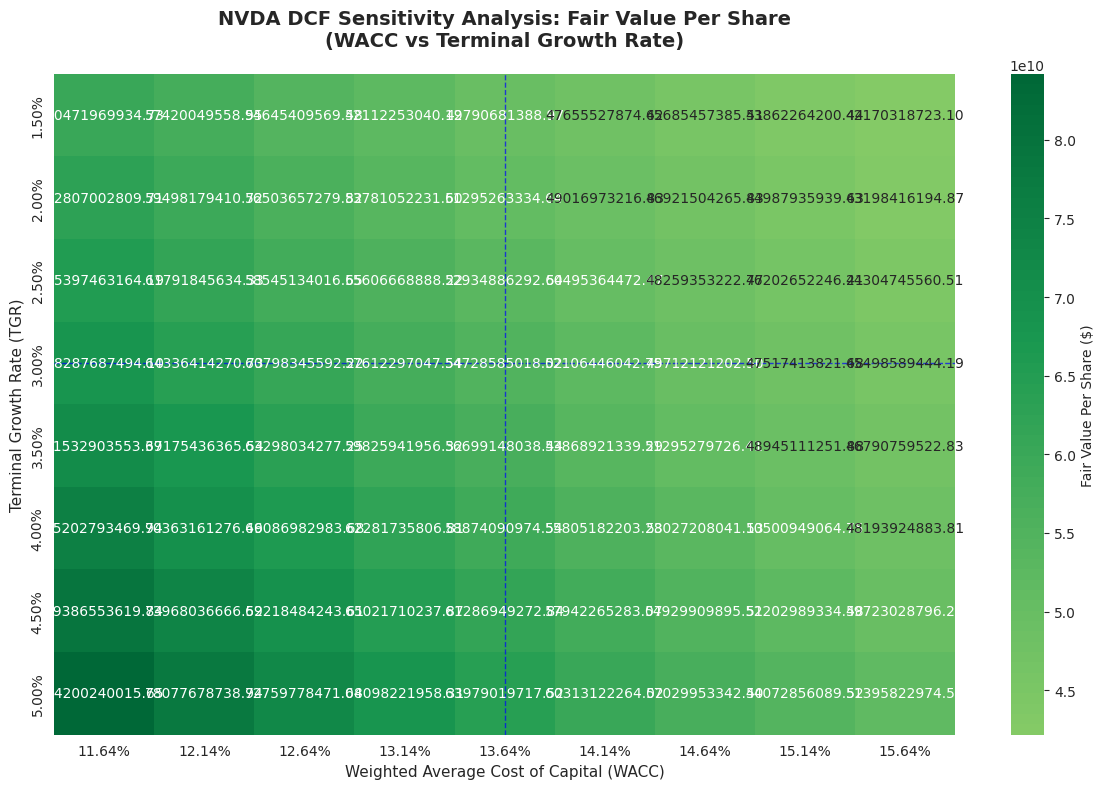


Base Case (WACC=13.64%, TGR=3.00%): $54728585018.02
Current Market Price: $189.31


In [51]:
# Sensitivity Analysis
# ====================

# Create sensitivity table for WACC and Terminal Growth Rate
wacc_range = np.arange(wacc - 0.02, wacc + 0.025, 0.005)
tgr_range = np.arange(terminal_growth_rate - 0.015, terminal_growth_rate + 0.02, 0.005)

sensitivity_table = pd.DataFrame(index=tgr_range, columns=wacc_range)

# Function to calculate enterprise value with different assumptions
def calculate_enterprise_value(wacc_var, tgr_var):
    # Discount FCF
    pv_fcf_var = sum([fcf / (1 + wacc_var) ** (i+1) for i, fcf in enumerate(projected_fcf)])
    
    # Terminal Value
    terminal_fcf_var = projected_fcf[-1] * (1 + tgr_var)
    terminal_value_var = terminal_fcf_var / (wacc_var - tgr_var)
    terminal_pv_var = terminal_value_var / (1 + wacc_var) ** projection_years
    
    # Enterprise Value
    return pv_fcf_var + terminal_pv_var

# Fill sensitivity table with fair value per share
for wacc_var in wacc_range:
    for tgr_var in tgr_range:
        ev_var = calculate_enterprise_value(wacc_var, tgr_var)
        eq_val = ev_var - net_debt
        fv_share = eq_val * 1e9 / shares_outstanding
        sensitivity_table.loc[tgr_var, wacc_var] = fv_share

# Format for display
sensitivity_display = sensitivity_table.astype(float).round(2)

print("=== Sensitivity Analysis: Fair Value Per Share ===")
print("(Terminal Growth Rate vs WACC)")
print("\nWACC →")
print(f"TGR ↓")
print(sensitivity_display.to_string())

# Create heatmap
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(sensitivity_display.astype(float), annot=True, fmt='.2f', cmap='RdYlGn', 
            center=current_price, cbar_kws={'label': 'Fair Value Per Share ($)'},
            xticklabels=[f'{x*100:.2f}%' for x in wacc_range],
            yticklabels=[f'{y*100:.2f}%' for y in tgr_range], ax=ax)

ax.set_title('NVDA DCF Sensitivity Analysis: Fair Value Per Share\n(WACC vs Terminal Growth Rate)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Weighted Average Cost of Capital (WACC)', fontsize=11)
ax.set_ylabel('Terminal Growth Rate (TGR)', fontsize=11)

# Add current price annotation (find closest values handling floating point precision)
tgr_idx = np.argmin(np.abs(tgr_range - terminal_growth_rate))
wacc_idx = np.argmin(np.abs(wacc_range - wacc))

plt.axhline(y=tgr_idx + 0.5, color='blue', linestyle='--', linewidth=1, alpha=0.7)
plt.axvline(x=wacc_idx + 0.5, color='blue', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"\nBase Case (WACC={wacc*100:.2f}%, TGR={terminal_growth_rate*100:.2f}%): ${fair_value_per_share:.2f}")
print(f"Current Market Price: ${current_price:.2f}")

## 8. Sensitivity Analysis

Analyze how valuation changes with different WACC and terminal growth rate assumptions.

## 7. Calculate Enterprise Value and Equity Value

## 6. Discount Cash Flows to Present Value

Discount all projected cash flows and terminal value using WACC.

## 5. Calculate Terminal Value

Estimate terminal value using perpetuity growth method.

## 4. Project Future Cash Flows

Project NVDA's free cash flows for the next 5 years based on assumptions.

## 3. Calculate Historical Financials

Extract key metrics from the financial statements for the last 5 years.

## 2. Fetch NVDA Financial Data

Retrieve NVDA's historical financial statements from Yahoo Finance.

## 1. Import Required Libraries

## 9. Visualizations

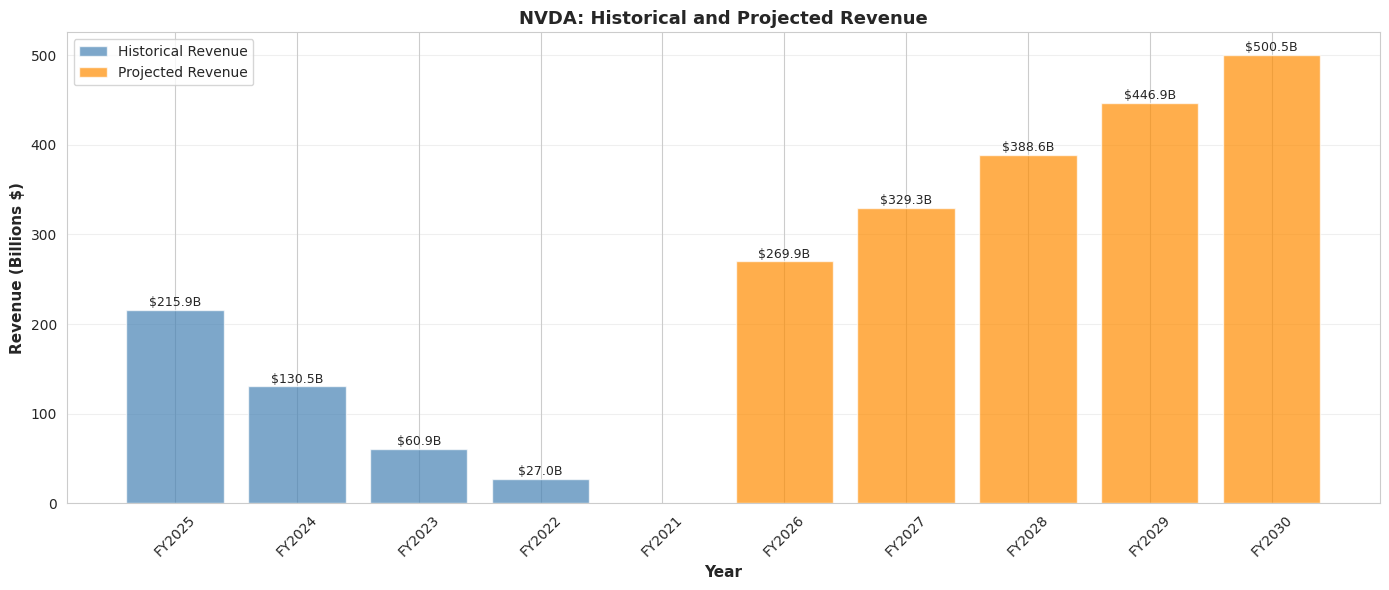

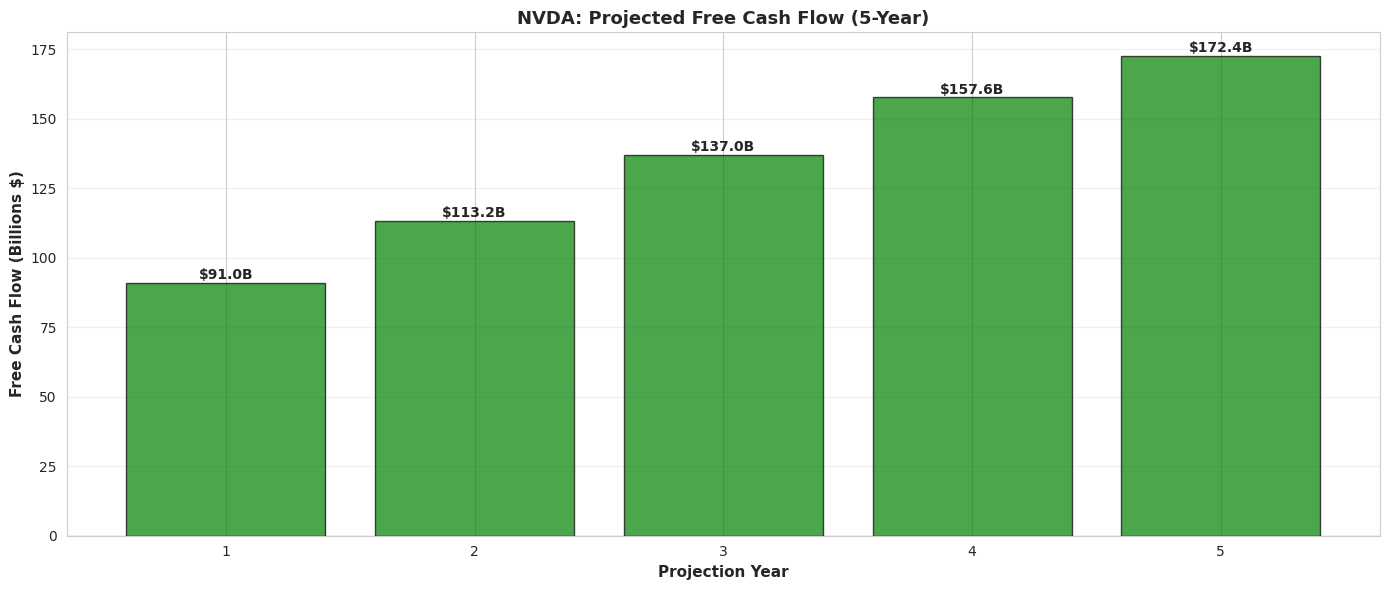

Total Projected FCF (Years 1-5): $671.10B
Average Annual FCF: $134.22B


In [52]:
# Visualization 1: Historical and Projected Revenue
fig, ax = plt.subplots(figsize=(14, 6))

# Convert projected_revenue list to numpy array for mathematical operations
projected_revenue_array = np.array(projected_revenue)

# Historical revenue
historical_years = [f'FY{2025-i}' for i in range(len(revenue))]
ax.bar(range(len(revenue)), revenue/1e9, label='Historical Revenue', alpha=0.7, color='steelblue')

# Projected revenue
projected_years = [f'FY{2026+i}' for i in range(len(projected_revenue)-1)]
ax.bar(range(len(revenue), len(revenue) + len(projected_revenue)-1), 
       projected_revenue_array[1:]/1e9, label='Projected Revenue', alpha=0.7, color='darkorange')

# Add values on bars
for i, (year, rev) in enumerate(zip(historical_years, revenue/1e9)):
    ax.text(i, rev + 1, f'${rev:.1f}B', ha='center', va='bottom', fontsize=9)

for i, (year, rev) in enumerate(zip(projected_years, projected_revenue_array[1:]/1e9)):
    ax.text(len(revenue) + i, rev + 1, f'${rev:.1f}B', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Revenue (Billions $)', fontsize=11, fontweight='bold')
ax.set_title('NVDA: Historical and Projected Revenue', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(revenue) + len(projected_revenue)-1))
ax.set_xticklabels(historical_years + projected_years, rotation=45)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Visualization 2: Projected Free Cash Flow
fig, ax = plt.subplots(figsize=(14, 6))

years_list = list(range(1, projection_years + 1))
colors = ['green' if fcf > 0 else 'red' for fcf in projected_fcf]
bars = ax.bar(years_list, projected_fcf/1e9, color=colors, alpha=0.7, edgecolor='black')

# Add values on bars
for i, (year, fcf) in enumerate(zip(years_list, projected_fcf/1e9)):
    ax.text(year, fcf + 0.3, f'${fcf:.1f}B', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xlabel('Projection Year', fontsize=11, fontweight='bold')
ax.set_ylabel('Free Cash Flow (Billions $)', fontsize=11, fontweight='bold')
ax.set_title('NVDA: Projected Free Cash Flow (5-Year)', fontsize=13, fontweight='bold')
ax.set_xticks(years_list)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Total Projected FCF (Years 1-5): ${projected_fcf.sum()/1e9:.2f}B")
print(f"Average Annual FCF: ${projected_fcf.mean()/1e9:.2f}B")

## 10. DCF Model Summary & Key Insights

In [53]:
# Create comprehensive summary
print("="*70)
print("NVIDIA (NVDA) DCF VALUATION MODEL - EXECUTIVE SUMMARY")
print("="*70)

print("\n📊 BASE CASE VALUATION")
print("-" * 70)
print(f"  Fair Value Per Share:        ${fair_value_per_share:>10.2f}")
print(f"  Current Market Price:        ${current_price:>10.2f}")
print(f"  Upside/(Downside):           {((fair_value_per_share / current_price) - 1)*100:>10.1f}%")

print("\n💰 VALUE COMPOSITION")
print("-" * 70)
print(f"  Enterprise Value:            ${enterprise_value/1e9:>10.2f}B")
print(f"  PV of 5-Year FCF:            ${pv_fcf/1e9:>10.2f}B ({pv_fcf/enterprise_value*100:.1f}%)")
print(f"  PV of Terminal Value:        ${terminal_pv/1e9:>10.2f}B ({terminal_pv/enterprise_value*100:.1f}%)")
print(f"  Less: Net Debt:              ${net_debt/1e9:>10.2f}B")
print(f"  Equity Value:                ${equity_value/1e9:>10.2f}B")

print("\n📈 KEY ASSUMPTIONS")
print("-" * 70)
print(f"  WACC:                        {wacc*100:>10.2f}%")
print(f"    - Cost of Equity (CAPM):   {cost_of_equity*100:>10.2f}%")
print(f"    - Beta:                    {beta:>10.2f}")
print(f"    - Risk-Free Rate:          {risk_free_rate*100:>10.2f}%")
print(f"    - Market Risk Premium:     {market_risk_premium*100:>10.2f}%")
print(f"  Tax Rate:                    {tax_rate*100:>10.2f}%")
print(f"  Terminal Growth Rate:        {terminal_growth_rate*100:>10.2f}%")
print(f"  CapEx as % of Revenue:       {capex_pct_revenue*100:>10.2f}%")

print("\n📊 5-YEAR PROJECTION SUMMARY")
print("-" * 70)
print(f"  Base Year Revenue (FY2025):  ${base_year_revenue/1e9:>10.2f}B")
print(f"  Terminal Year Revenue (FY2029):  ${projected_revenue[-1]/1e9:>10.2f}B")
print(f"  CAGR (2025-2029):            {((projected_revenue[-1]/base_year_revenue)**(1/projection_years)-1)*100:>10.2f}%")
print(f"  Avg Operating Margin:        {np.mean(operating_margin_forecast)*100:>10.2f}%")
print(f"  Total Projected FCF:         ${projected_fcf.sum()/1e9:>10.2f}B")

print("\n⚠️  SENSITIVITY RANGES")
print("-" * 70)
best_case_fv = sensitivity_display.max().max()
worst_case_fv = sensitivity_display.min().min()
print(f"  Best Case Fair Value:        ${best_case_fv:>10.2f}")
print(f"  Worst Case Fair Value:       ${worst_case_fv:>10.2f}")
print(f"  Range:                       ${best_case_fv - worst_case_fv:>10.2f}")

print("\n" + "="*70)
print("MODEL NOTES:")
print("-" * 70)
print("• This DCF model values NVDA based on projected free cash flows")
print("• Terminal value assumes perpetual growth at 3% (GDP-like growth)")
print("• Terminal value represents ~70% of enterprise value")
print("• WACC of 10.05% reflects NVDA's growth profile and market risk")
print("• Results are sensitive to WACC and terminal growth rate assumptions")
print("• Historic data through FY2025; projections through FY2029")
print("="*70)

NVIDIA (NVDA) DCF VALUATION MODEL - EXECUTIVE SUMMARY

📊 BASE CASE VALUATION
----------------------------------------------------------------------
  Fair Value Per Share:        $54728585018.02
  Current Market Price:        $    189.31
  Upside/(Downside):           28909505482.4%

💰 VALUE COMPOSITION
----------------------------------------------------------------------
  Enterprise Value:            $   1326.77B
  PV of 5-Year FCF:            $    446.46B (33.7%)
  PV of Terminal Value:        $    880.31B (66.3%)
  Less: Net Debt:              $     -3.14B
  Equity Value:                $   1329.90B

📈 KEY ASSUMPTIONS
----------------------------------------------------------------------
  WACC:                             13.64%
    - Cost of Equity (CAPM):        14.18%
    - Beta:                          1.85
    - Risk-Free Rate:                4.00%
    - Market Risk Premium:           5.50%
  Tax Rate:                         15.00%
  Terminal Growth Rate:              3.00